In [1]:
#!python -m spacy download en_core_web_sm

In [1]:
import spacy

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from lexicalrichness import LexicalRichness


In [2]:
data = pd.read_csv('../data/clean_data/kaggle_dataset.csv')


#### Basic Analysis

Corpus size       : 487231 texts
AI-generated      : 181434 (37.24%)
Human-written     : 305797 (62.76%)


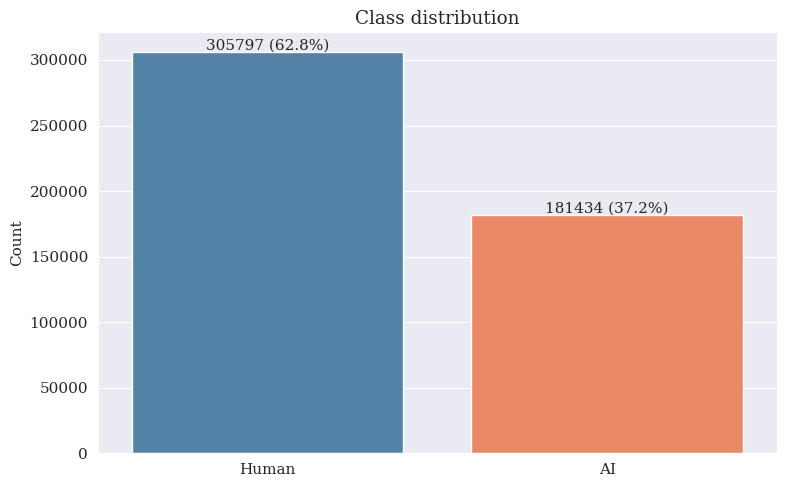

In [5]:
n = data.shape[0]
n_ai = int(data.generated.sum())
pct_ai = n_ai / n * 100

print(f"Corpus size       : {n} texts")
print(f"AI-generated      : {n_ai} ({pct_ai:.2f}%)")
print(f"Human-written     : {n - n_ai} ({100 - pct_ai:.2f}%)")


fig, ax = plt.subplots(figsize=(8, 5))
plt.rcParams["font.family"] = 'Serif'
plt.rcParams["font.size"] = 11
plt.rcParams["figure.facecolor"] = "white"
sns.countplot(data=data, x="generated", hue="generated",
              legend=False, ax=ax,
              palette=["steelblue", "coral"])
ax.set_xticks([0, 1])
ax.set_xticklabels(["Human", "AI"])
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.set_title("Class distribution")
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f"{height} ({height/n*100:.1f}%)",
                (p.get_x() + p.get_width()/2, height),
                ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.savefig("figures/kaggle_dataset.png")
plt.show()

In [6]:
# As there are more human texts than AI-generated one, we sample human texts to have balanced classes

# count minority class
n_minority = data["generated"].value_counts().min()

# sample each class

df_balanced = (data.groupby("generated")
                   .sample(n=n_minority, random_state=32)
                   .reset_index(drop=True))

print(df_balanced["generated"].value_counts())

generated
0    181434
1    181434
Name: count, dtype: int64


# 1. Lexical and surface features

In [7]:
import re

def count_unique_words(text):
    words = re.findall(r"\b\w+\b", text.lower())
    return len(set(words))
def count_words(text):
    return len(text.split())

df_balanced["word_count"] = df_balanced["text"].apply(count_words)
df_balanced["vocab_size"] = df_balanced["text"].apply(count_unique_words)
df_balanced["vocab_richness"] = df_balanced["vocab_size"]/df_balanced["word_count"]
L = df_balanced.groupby('generated')['word_count'].mean()
V = df_balanced.groupby('generated')['vocab_size'].mean()
TTF = V/L

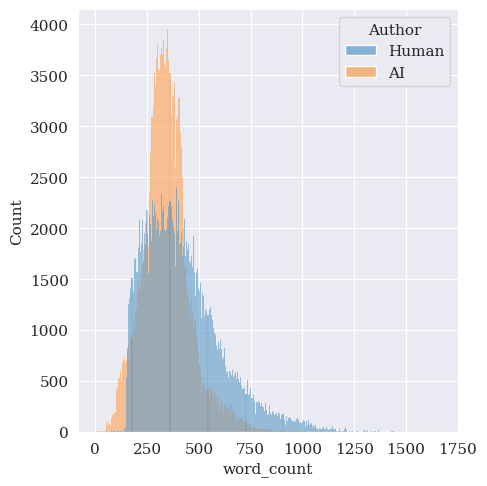

In [14]:
plt.figure(figsize=(5, 5))
ax = sns.histplot(data=df_balanced, x="word_count", hue="generated")

legend = ax.get_legend()
legend.set_title("Author")
for t, label in zip(legend.get_texts(), ["Human", "AI"]):
    t.set_text(label)

plt.tight_layout()
plt.savefig("figures/word_count.png")
plt.show()

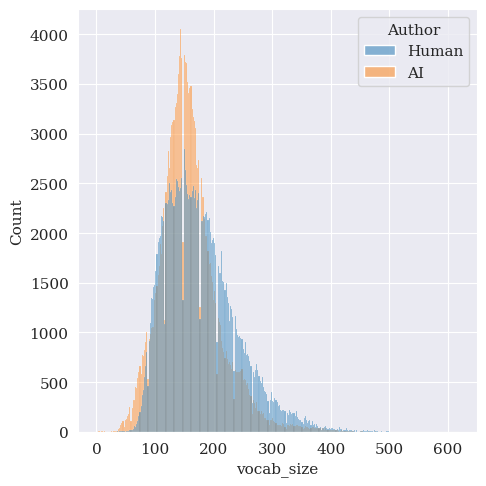

In [15]:
plt.figure(figsize=(5, 5))
ax = sns.histplot(data=df_balanced, x="vocab_size", hue="generated")

# Rename legend labels
legend = ax.get_legend()
legend.set_title("Author")
for t, label in zip(legend.get_texts(), ["Human", "AI"]):
    t.set_text(label)

plt.tight_layout()
plt.savefig("figures/vocab_size.png")
plt.show()

### Vocabulary richness analysis

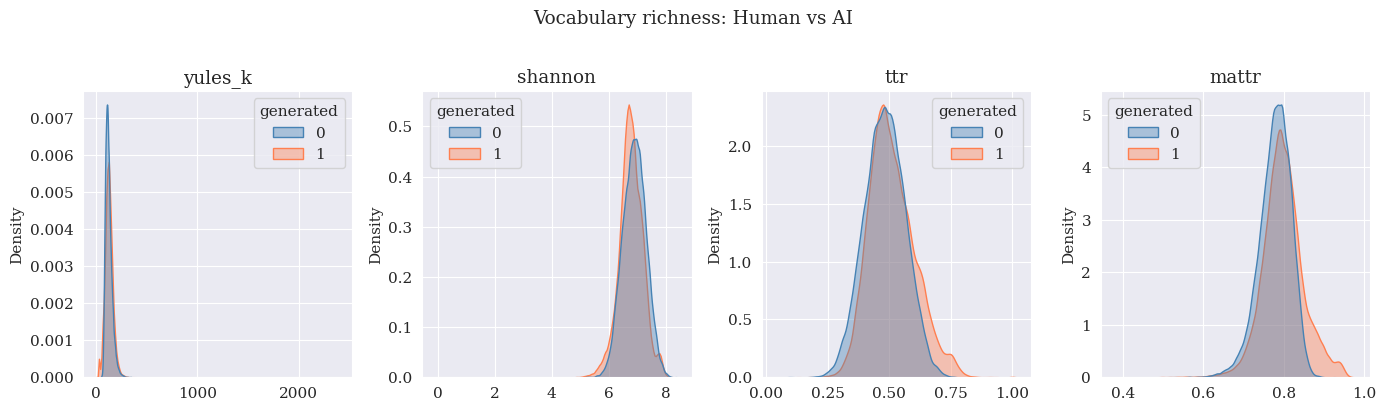

In [16]:
def yules_k(text):
    words = text.lower().split()
    counts = Counter(words)
    M1 = len(words)                          # total tokens
    M2 = sum(v**2 for v in counts.values())  # sum of squared frequencies
    K = 10**4 * (M2 - M1) / (M1**2)
    return K

def shannon_entropy(text):
    words = text.lower().split()
    counts = Counter(words)
    total = len(words)
    probs = [c / total for c in counts.values()]
    return -sum(p * np.log2(p) for p in probs)

def ttr(text):
    words = text.lower().split()
    return len(set(words)) / len(words)

def mattr(text, window_size=50):
    lex = LexicalRichness(text)
    try:
        return lex.mattr(window_size=window_size)
    except:
        return np.nan

# apply
df_balanced["yules_k"] = df_balanced["text"].apply(yules_k)
df_balanced["shannon"] = df_balanced["text"].apply(shannon_entropy)
df_balanced["ttr"] = df_balanced["text"].apply(ttr)
df_balanced["mattr"] = df_balanced["text"].apply(mattr)

metrics = ["yules_k", "mattr"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric in zip(axes, metrics):
    sns.kdeplot(data=df_balanced, x=metric, hue="generated",
                fill=True, alpha=0.4,
                palette={0: "steelblue", 1: "coral"}, ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("figures/vocabulary_richness.png")
plt.show()

In [20]:
# To no eyeball the mean of the distribution
df_balanced.groupby('generated')['yules_k'].mean()

generated
0    119.497070
1    123.194344
Name: yules_k, dtype: float64

In [21]:
df_balanced.groupby('generated')['mattr'].mean()

generated
0    0.777049
1    0.797274
Name: mattr, dtype: float64

In [27]:
from scipy import stats

variables = ['yules_k', 'mattr']

for var in variables:
    human = df_balanced[df_balanced["generated"] == 0][var].copy().dropna()
    ai = df_balanced[df_balanced["generated"] == 1][var].copy().dropna()

    t_stat, p_value = stats.mannwhitneyu(human, ai)
    print(f"{var}| p-value: {p_value:.4f}")

yules_k| p-value: 0.0000
mattr| p-value: 0.0000


In [28]:
def cohens_d(group1, group2):
    pooled_std = np.sqrt((group1.std()**2 + group2.std()**2) / 2)
    return (group2.mean() - group1.mean()) / pooled_std
variables = ['yules_k', 'mattr']

for var in variables:
    human = df_balanced[df_balanced["generated"] == 0][var].copy().dropna()
    ai = df_balanced[df_balanced["generated"] == 1][var].copy().dropna()
    stat = cohens_d(human, ai)
    print(f"Cohen's d {var}: {stat:.4f}")


Cohen's d yules_k: 0.1022
Cohen's d mattr: 0.4380


### Part-of-speech tagging

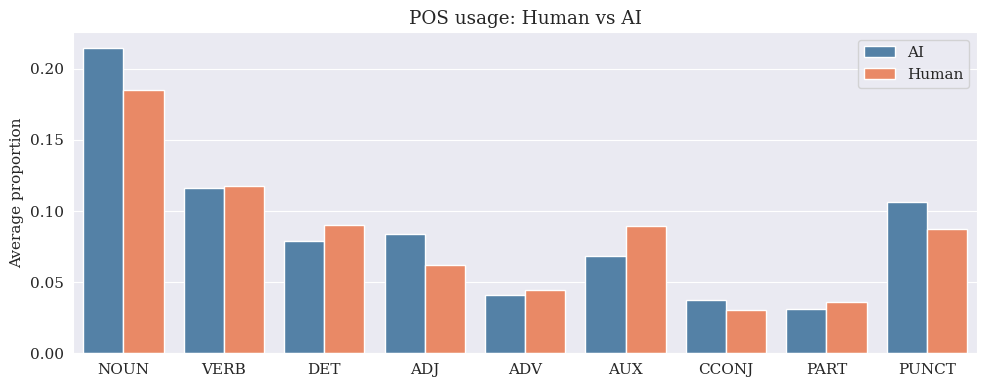

In [29]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "lemmatizer"])

def get_pos_counts_pipe(texts, batch_size=64):
    results = []
    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=-1):
        total = len(doc)
        counts = {}
        for token in doc:
            counts[token.pos_] = counts.get(token.pos_, 0) + 1
        results.append({k: v / total for k, v in counts.items()})
    return pd.DataFrame(results).fillna(0)

pos_df = get_pos_counts_pipe(df_balanced["text"])
pos_df["label"] = df_balanced["generated"].map({0: "Human", 1: "AI"})

# rest unchanged
main_pos = ["NOUN", "VERB", "DET", "ADJ", "ADV", "AUX", "CCONJ", "PART", "PUNCT"]
pos_avg  = pos_df.groupby("label").mean()[main_pos]

pos_melted = pos_avg.reset_index().melt(id_vars="label",
                                        var_name="POS",
                                        value_name="proportion")

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=pos_melted, x="POS", y="proportion",
            hue="label", palette=["steelblue", "coral"], ax=ax)
ax.set_title("POS usage: Human vs AI")
ax.set_xlabel("")
ax.set_ylabel("Average proportion")
ax.legend(title="")
plt.tight_layout()
plt.savefig("figures/pos_usage.png")
plt.show()

it is also interesting to understand probability transition from one tag to another to uncounter language biais etc... To do so we use a POS Bigram Model.

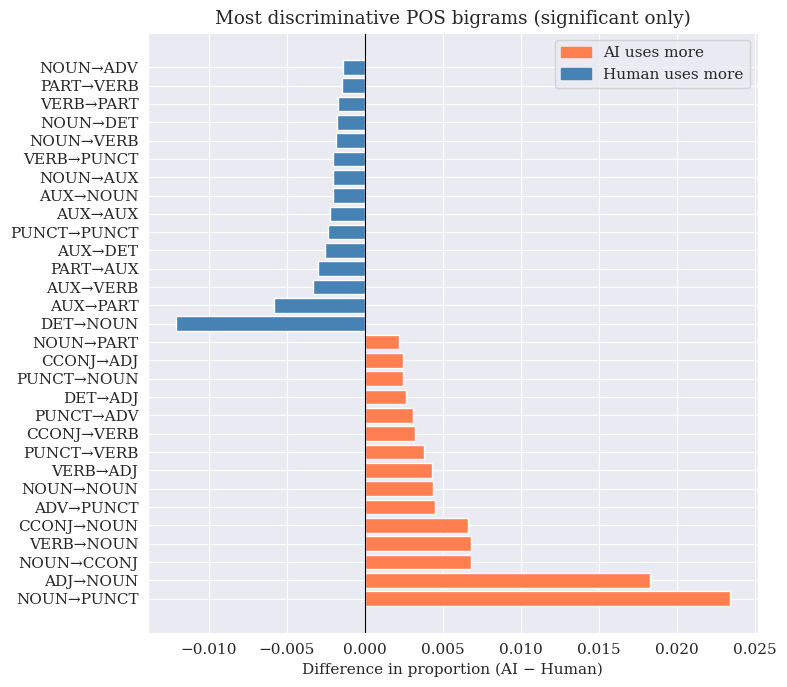

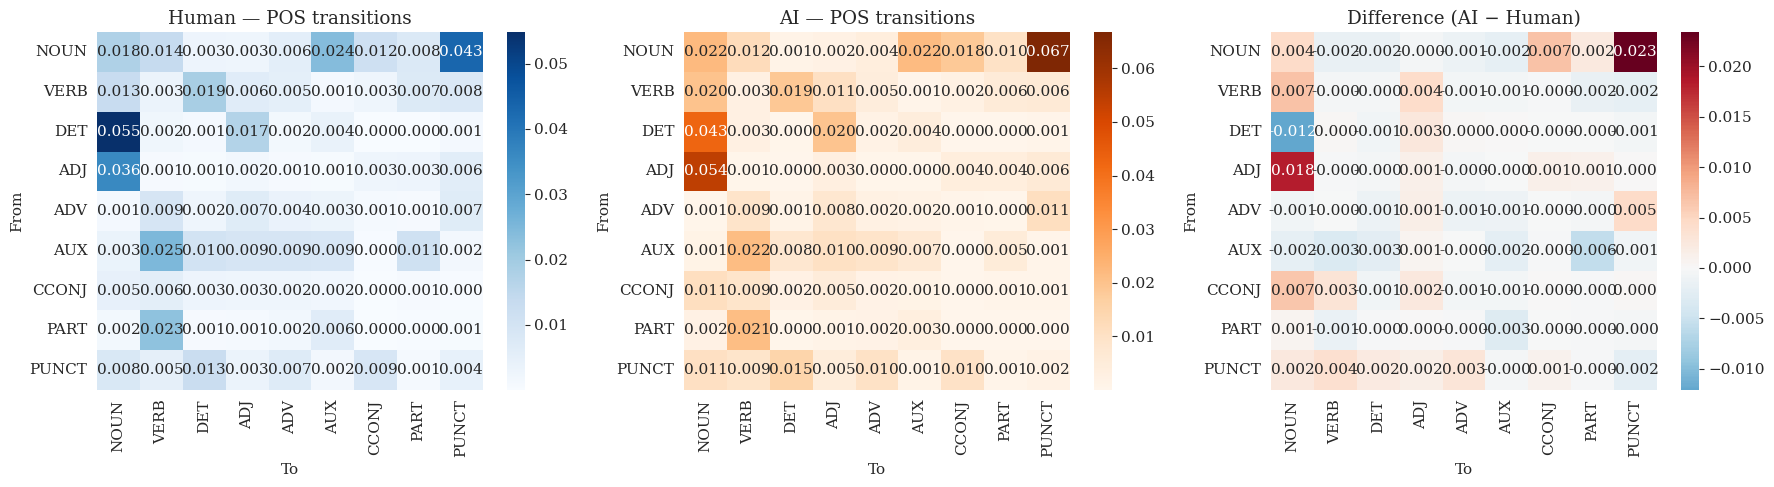

In [30]:
from scipy import stats
MAIN_POS = main_pos  # reuse from above

def extract_bigrams(texts, batch_size=64):
    results = []
    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=-1):
        pos     = [t.pos_ for t in doc]
        bigrams = [f"{pos[i]}→{pos[i+1]}" for i in range(len(pos)-1)]
        total   = len(bigrams) if bigrams else 1
        counts  = Counter(bigrams)
        results.append({k: v / total for k, v in counts.items()})
    return pd.DataFrame(results).fillna(0)

bigram_df              = extract_bigrams(df_balanced["text"])
bigram_df["generated"] = df_balanced["generated"].values

# filter to main POS only
main_cols = [c for c in bigram_df.columns
             if c != "generated"
             and c.split("→")[0] in MAIN_POS
             and c.split("→")[1] in MAIN_POS]
bigram_df = bigram_df[main_cols + ["generated"]]

bigram_avg = bigram_df.groupby("generated").mean()
diff       = bigram_avg.loc[1] - bigram_avg.loc[0]

results = []
for col in main_cols:
    ai    = bigram_df[bigram_df.generated == 1][col]
    human = bigram_df[bigram_df.generated == 0][col]
    _, p  = stats.mannwhitneyu(ai, human, alternative="two-sided")
    results.append({"bigram": col, "diff": ai.mean() - human.mean(), "p": p})

results_df = pd.DataFrame(results).sort_values("p")
sig        = results_df[results_df.p < 0.05].set_index("bigram")

sig_diff = diff[diff.index.isin(sig.index)]
top      = pd.concat([sig_diff.nlargest(15), sig_diff.nsmallest(15)])

fig, ax = plt.subplots(figsize=(8, 7))
colors  = ["coral" if v > 0 else "steelblue" for v in top.values]
ax.barh(top.index, top.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Difference in proportion (AI − Human)")
ax.set_title("Most discriminative POS bigrams (significant only)")
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color="coral",     label="AI uses more"),
    plt.Rectangle((0,0),1,1, color="steelblue", label="Human uses more")
])
plt.tight_layout()
plt.savefig("figures/sig_diff.png")
plt.show()

def transition_matrix(df, label):
    subset = df[df.generated == label].drop(columns="generated")
    matrix = pd.DataFrame(0.0, index=MAIN_POS, columns=MAIN_POS)
    for col in subset.columns:
        a, b = col.split("→")
        if a in MAIN_POS and b in MAIN_POS:
            matrix.loc[a, b] = subset[col].mean()
    return matrix

mat_human = transition_matrix(bigram_df, 0)
mat_ai    = transition_matrix(bigram_df, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(mat_human,          ax=axes[0], cmap="Blues",   annot=True, fmt=".3f")
sns.heatmap(mat_ai,             ax=axes[1], cmap="Oranges", annot=True, fmt=".3f")
sns.heatmap(mat_ai - mat_human, ax=axes[2], cmap="RdBu_r",
            center=0, annot=True, fmt=".3f")

axes[0].set_title("Human — POS transitions")
axes[1].set_title("AI — POS transitions")
axes[2].set_title("Difference (AI − Human)")
for ax in axes:
    ax.set_xlabel("To")
    ax.set_ylabel("From")

plt.tight_layout()
plt.savefig("figures/transition_matrix.png")
plt.show()

# 2. Sentiment Analysis

In [12]:
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

def compute_sentiment_features(text):
    if pd.isna(text):
        text = ""
    text = str(text)

    # TextBlob — polarity [-1, 1] and subjectivity [0, 1]
    blob = TextBlob(text)
    polarity     = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity

    # VADER — better for informal text, gives pos/neg/neu/compound
    scores = vader.polarity_scores(text)

    return {
        "polarity"        : polarity,
        "subjectivity"    : subjectivity,
        "vader_positive"  : scores["pos"],
        "vader_negative"  : scores["neg"],
        "vader_neutral"   : scores["neu"],
        "vader_compound"  : scores["compound"],
    }

sentiment_df = pd.DataFrame(df_balanced["text"].apply(compute_sentiment_features).tolist())
sentiment_df["generated"] = df_balanced["generated"].values

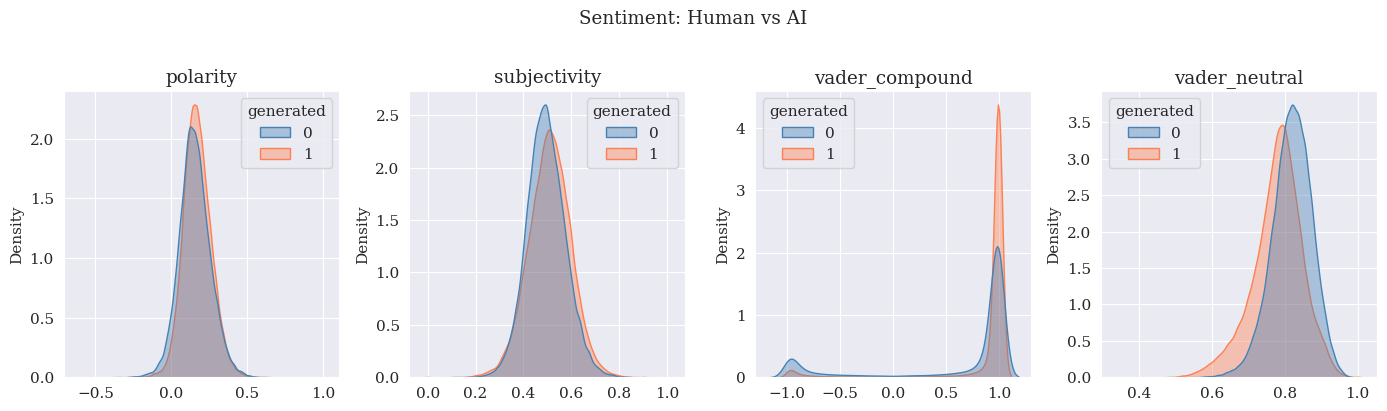

In [13]:
metrics = ["polarity", "subjectivity", "vader_compound", "vader_neutral"]

fig, axes = plt.subplots(1, len(metrics), figsize=(14, 4))
for ax, metric in zip(axes, metrics):
    sns.kdeplot(data=sentiment_df, x=metric, hue="generated",
                fill=True, alpha=0.4,
                palette={0: "steelblue", 1: "coral"}, ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("")

plt.suptitle("Sentiment: Human vs AI", y=1.02)
plt.tight_layout()
plt.show()

# 3. Semantic Analysis

### 3.1 TD-IDF - most characteristic words per class

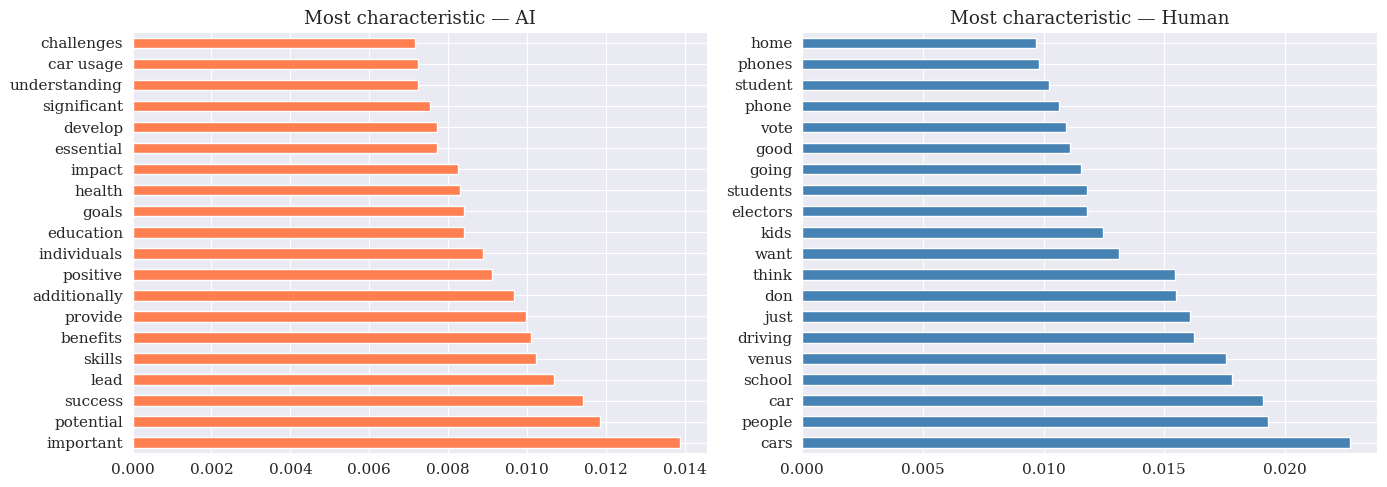

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words="english")
X     = tfidf.fit_transform(df_balanced["text"])

# average TF-IDF score per class
feature_names = tfidf.get_feature_names_out()
ai_mask       = df_balanced["generated"].values == 1
human_mask    = ~ai_mask

ai_scores    = X[ai_mask].mean(axis=0).A1
human_scores = X[human_mask].mean(axis=0).A1
diff         = ai_scores - human_scores

# top words per class
top_ai    = pd.Series(diff, index=feature_names).nlargest(20)
top_human = pd.Series(diff, index=feature_names).nsmallest(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_ai.plot.barh(ax=axes[0], color="coral")
axes[0].set_title("Most characteristic — AI")
top_human.abs().plot.barh(ax=axes[1], color="steelblue")
axes[1].set_title("Most characteristic — Human")
plt.tight_layout()
plt.show()

### 3.2 Topic modelling - Do AI covers topics differently than Human?

Topic 0: votes | popular | mars | states | face | president | vote | college | electoral college | electoral
Topic 1: multiple | animals | luke | seagoing cowboys | people | program | cowboy | cowboys | seagoing | advice
Topic 2: driving | attitude | important | failure | positive | phone | life | people | like | success
Topic 3: studying venus | studying | exploring venus | atmosphere | exploring | surface | earth | author | planet | venus
Topic 4: helping | young people | make | think | students | help | people | community service | service | community
Topic 5: air | public | reduce | cars | transportation | limiting car | limiting | car usage | usage | car
Topic 6: paris | air | people | driving | car usage | pollution | smog | usage | cars | car
Topic 7: road | driverless car | drive | driver | driving | technology | car | driverless cars | cars | driverless
Topic 8: technology | emotions | summer | online | facial | classes | learning | school | student | students
Topic 9: cell | 

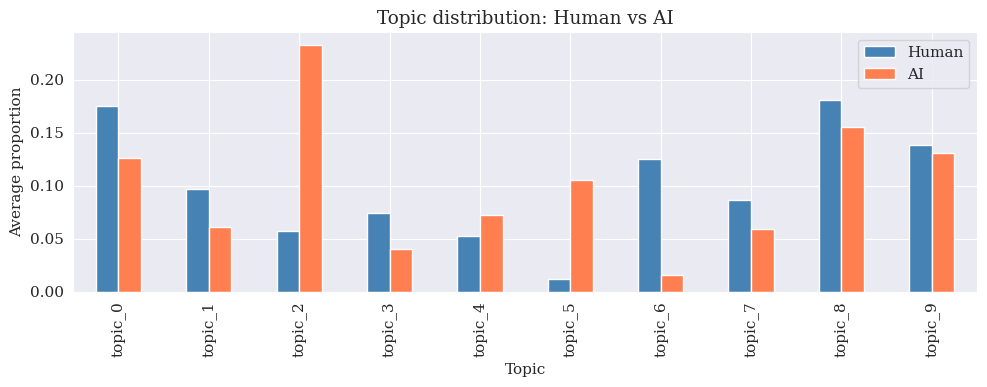

In [15]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=10, random_state=23)
lda.fit(X)

def print_topics(model, feature_names, n_words=10):
    for i, topic in enumerate(model.components_):
        top_words = [feature_names[j] for j in topic.argsort()[-n_words:]]
        print(f"Topic {i}: {' | '.join(top_words)}")

print_topics(lda, feature_names)

# topic distribution per class
topic_dist = lda.transform(X)
topic_df   = pd.DataFrame(topic_dist, columns=[f"topic_{i}" for i in range(10)])
topic_df["generated"] = df_balanced["generated"].values

topic_avg = topic_df.groupby("generated").mean()
topic_avg.T.plot.bar(figsize=(10, 4), color=["steelblue", "coral"])
plt.title("Topic distribution: Human vs AI")
plt.xlabel("Topic")
plt.ylabel("Average proportion")
plt.legend(["Human", "AI"])
plt.tight_layout()
plt.show()

### 3.3 Sentence embeddings

/Users/louis-armandaumont/Detect-LLM/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 16484.65it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 5670/5670 [41:58<00:00,  2.25it/s]


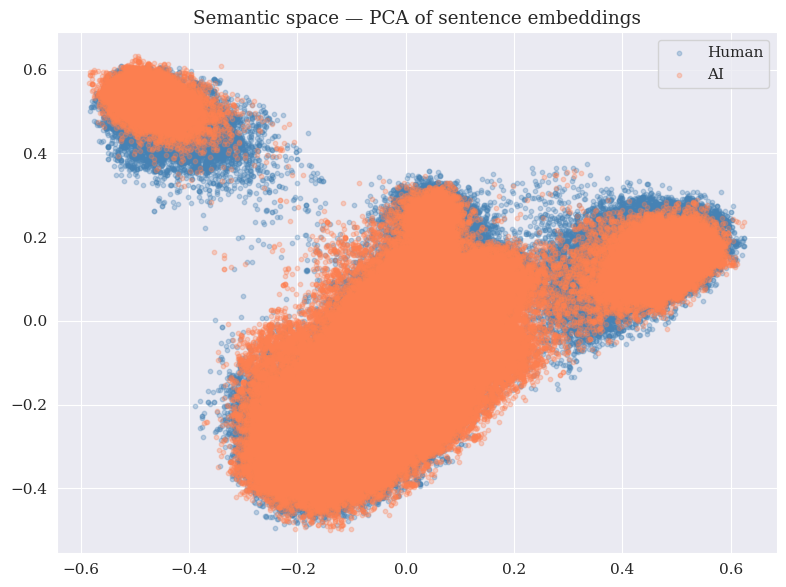

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

model      = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(df_balanced["text"].tolist(), batch_size=64, show_progress_bar=True)

# 2D PCA to visualize semantic space
pca    = PCA(n_components=2, random_state=23)
coords = pca.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in zip([0, 1], ["steelblue", "coral"], ["Human", "AI"]):
    mask = df_balanced["generated"].values == label
    ax.scatter(coords[mask, 0], coords[mask, 1],
               alpha=0.3, s=10, color=color, label=name)
ax.set_title("Semantic space — PCA of sentence embeddings")
ax.legend()
plt.tight_layout()
plt.show()

# semantic diversity per class — average pairwise cosine similarity
# high similarity = less diverse, more repetitive
for label, name in zip([0, 1], ["Human", "AI"]):
    mask    = df_balanced["generated"].values == label
    emb     = embeddings[mask]
    sim     = cosine_similarity(emb)
    np.fill_diagonal(sim, 0)
    avg_sim = sim.sum() / (len(emb) * (len(emb) - 1))
    print(f"{name} avg cosine similarity: {avg_sim:.4f}")

### 3.4 Perplexity

In [ ]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import torch

tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
gpt2      = GPT2LMHeadModel.from_pretrained("gpt2")
gpt2.eval()

def compute_perplexity(text, max_length=512):
    inputs = tokenizer(text, return_tensors="pt",
                       truncation=True, max_length=max_length)
    with torch.no_grad():
        loss = gpt2(**inputs, labels=inputs["input_ids"]).loss
    return torch.exp(loss).item()

df_balanced["perplexity"] = df_balanced["text"].apply(compute_perplexity)

fig, ax = plt.subplots(figsize=(6, 4))
sns.kdeplot(data=df_balanced, x="perplexity", hue="generated",
            fill=True, alpha=0.4,
            palette={0: "steelblue", 1: "coral"}, ax=ax)
ax.set_title("Perplexity distribution: Human vs AI")
ax.set_xlabel("Perplexity (GPT-2)")
plt.tight_layout()
plt.show()

/Users/louis-armandaumont/Detect-LLM/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
